# TP Final — Notebook 02: Regresión (modelado y selección)
### Estimación de precios de alquiler

Segunda etapa del pipeline. Toma el `train.csv` / `test.csv` que generó
`01_eda_limpieza.ipynb` y construye el modelo de regresión:

1. Ablación de `pets_allowed` (pipeline completo con missing → `"no"` vs `drop` de la variable).
2. **Baselines** (mediana global, mediana por ciudad, regresión lineal).
3. **Búsqueda de hiperparámetros con `GridSearchCV`** sobre **varias familias de modelos**
   (lineal, red neuronal, bosques, boosting) — sin casarse con ninguna: se eligen por mérito.
   Grids acotados (RF con profundidad limitada) para evitar overfitting y tiempos largos.
4. Comparación con métricas adecuadas (**MAE, RMSE, MAPE**) y selección del mejor + **gráficos
   de los GridSearch** para la diapositiva.
5. Evaluación en test + **rango** = banda relativa calibrada con los residuos del mejor modelo.

> No se premia usar un modelo complejo si uno simple alcanza: por eso comparamos contra
> baselines y entre familias.

## 0. Setup

In [1]:
import importlib, subprocess, sys
REQUIRED = {"pandas":"pandas","numpy":"numpy","scikit-learn":"sklearn",
            "lightgbm":"lightgbm","xgboost":"xgboost","matplotlib":"matplotlib",
            "seaborn":"seaborn","joblib":"joblib"}
missing = [p for p,i in REQUIRED.items() if importlib.util.find_spec(i) is None]
if missing:
    print("Instalando:", missing)
    subprocess.check_call([sys.executable,"-m","pip","install","-q",*missing])
else:
    print("Dependencias OK")


Dependencias OK


In [2]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 42
PROC = Path("data/processed"); OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

assert (PROC/"train.csv").exists(), "Falta data/processed/train.csv — corré 01_eda_limpieza.ipynb primero"
train = pd.read_csv(PROC/"train.csv")
test  = pd.read_csv(PROC/"test.csv")
print("train:", train.shape, "| test:", test.shape)

train: (39060, 20) | test: (9766, 20)


## 1. Definición del target y de las features

El target es `price`. Por la fuerte asimetría (visto en NB1) modelamos en **escala
logarítmica** vía `TransformedTargetRegressor` (`log1p`/`expm1`): el modelo aprende sobre
`log(precio)` pero **las métricas y la selección se calculan en USD reales**.

In [3]:
TARGET = "price"
NUM_FEATURES = ["square_feet","bedrooms","bathrooms","latitude","longitude",
                "dist_city_center","knn_price","city_price_median","city_price_mean",
                "n_amenities","has_amenities","has_photo_bin","fee_bin","pets_known"]
# 'state' es categórica; la columna de mascotas se define en la ablación (sección 2).

y_train = train[TARGET].to_numpy()
y_test  = test[TARGET].to_numpy()

def metrics(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "MAPE%": mean_absolute_percentage_error(y_true, y_pred) * 100}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 2. Ablación de `pets_allowed`

Corremos el **pipeline completo** de dos maneras y comparamos por CV (MAE real, mismo
modelo rápido LightGBM):

- **`as_no`**: faltante → `"no"` (se asume que no admite mascotas); la variable entra al modelo.
- **`drop`**: se **elimina** la categoría `pets_allowed` del modelo (baseline sin mascotas).

Así medimos si `pets_allowed` aporta señal real o es ruido. El ganador define `PETS_MODE`.
(El flag de missingness `pets_known` se mantiene igual en ambos casos: lo que varía es si la
categoría admite/no-admite entra al modelo.)

In [4]:
def make_X(df, mode):
    X = df[NUM_FEATURES + ["state"]].copy()
    if mode == "as_no":                 # faltante -> "no"; la categoría entra al modelo
        X["pets_cat"] = df["pets_filled_no"]
    # mode == "drop": no se agrega columna de mascotas (baseline sin pets)
    return X

def make_pipeline(estimator):
    # Selección de categóricas por dtype: robusto a que 'pets_cat' esté o no presente.
    pre = ColumnTransformer([
        ("num", StandardScaler(), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         make_column_selector(dtype_include=object)),
    ])
    pipe = Pipeline([("prep", pre), ("model", estimator)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

pets_scores = {}   # mode -> MAE CV (para el gráfico de ablación)
for mode in ["as_no", "drop"]:
    Xa = make_X(train, mode)
    est = make_pipeline(LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31,
                                      random_state=RANDOM_STATE, verbose=-1))
    sc = -cross_val_score(est, Xa, y_train, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
    pets_scores[mode] = sc.mean()
    print(f"pets={mode:<8}  MAE CV = {sc.mean():7.2f} +/- {sc.std():5.2f}")

/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


pets=as_no     MAE CV =  176.82 +/-  1.35


/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

pets=drop      MAE CV =  176.78 +/-  1.50


/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [5]:
# Elegimos la codificación con menor MAE de CV (as_no vs drop)
PETS_MODE = min(pets_scores, key=pets_scores.get)
print("PETS_MODE elegido:", PETS_MODE, "| MAE CV =", round(pets_scores[PETS_MODE], 2))

X_train = make_X(train, PETS_MODE)
X_test  = make_X(test,  PETS_MODE)
print("Features finales:", list(X_train.columns))

PETS_MODE elegido: drop | MAE CV = 176.78
Features finales: ['square_feet', 'bedrooms', 'bathrooms', 'latitude', 'longitude', 'dist_city_center', 'knn_price', 'city_price_median', 'city_price_mean', 'n_amenities', 'has_amenities', 'has_photo_bin', 'fee_bin', 'pets_known', 'state']


## 3. Baselines

Antes de cualquier modelo, fijamos referencias simples. Si un modelo no las supera, no
justifica su complejidad.

- **Mediana global**: predice siempre la mediana de train.
- **Mediana por ciudad**: predice `city_price_median` (ya calculado en train, sección NB1).
- **Regresión lineal**: baseline lineal con todas las features.

In [6]:
results = {}   # nombre -> dict de métricas en TEST

# baseline 1: mediana global
dummy = DummyRegressor(strategy="median").fit(X_train, y_train)
results["Baseline: mediana global"] = metrics(y_test, dummy.predict(X_test))

# baseline 2: mediana por ciudad (columna ya disponible)
results["Baseline: mediana por ciudad"] = metrics(y_test, test["city_price_median"].to_numpy())

# baseline 3: regresión lineal
lin = make_pipeline(LinearRegression()).fit(X_train, y_train)
results["Baseline: regresión lineal"] = metrics(y_test, lin.predict(X_test))

pd.DataFrame(results).T.round(2)


,MAE,RMSE,MAPE%
Baseline: mediana global,494.45,762.31,32.92
Baseline: mediana por ciudad,344.55,547.38,22.58
Baseline: regresión lineal,243.53,418.38,15.56


## 4. Búsqueda de hiperparámetros (`GridSearchCV`) por familia de modelos

Probamos **varias familias** y dejamos que los datos decidan. Para cada una, `GridSearchCV`
(5-fold, refit por **MAE**) busca la mejor configuración. Grids deliberadamente acotados
para que el notebook sea **reproducible en tiempo razonable**.

In [7]:
SCORING = "neg_mean_absolute_error"

GRIDS = {
    "Ridge": (Ridge(random_state=RANDOM_STATE),
              {"regressor__model__alpha": [0.1, 1.0, 10.0, 100.0]}),

    # ANN (perceptrón multicapa) en reemplazo de KNN: red chica, con early_stopping
    # y regularización L2 (alpha) para no memorizar.
    "ANN": (MLPRegressor(random_state=RANDOM_STATE, max_iter=300,
                         early_stopping=True, n_iter_no_change=10),
            {"regressor__model__hidden_layer_sizes": [(64,), (64, 32)],
             "regressor__model__alpha": [1e-4, 1e-2]}),

    # RF acotado en profundidad: max_depth grande => memoriza (overfit) y tarda mucho.
    # Regularizamos con min_samples_leaf en vez de dejar crecer los árboles.
    "RandomForest": (RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
                     {"regressor__model__max_depth": [12, 20],
                      "regressor__model__min_samples_leaf": [5, 20]}),

    "HistGBR": (HistGradientBoostingRegressor(random_state=RANDOM_STATE),
                {"regressor__model__learning_rate": [0.05, 0.1],
                 "regressor__model__max_iter": [300, 600],
                 "regressor__model__max_leaf_nodes": [31, 63]}),

    "XGBoost": (XGBRegressor(n_estimators=500, subsample=0.8, colsample_bytree=0.8,
                             random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
                {"regressor__model__max_depth": [6, 8],
                 "regressor__model__learning_rate": [0.03, 0.07]}),

    "LightGBM": (LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
                 {"regressor__model__n_estimators": [400, 800],
                  "regressor__model__num_leaves": [31, 63],
                  "regressor__model__learning_rate": [0.05]}),
}

In [8]:
import time
searches = {}   # nombre -> GridSearchCV ajustado

for name, (est, grid) in GRIDS.items():
    t0 = time.time()
    gs = GridSearchCV(make_pipeline(est), grid, scoring=SCORING, cv=cv, n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f"{name:<13} mejor MAE CV = {-gs.best_score_:7.2f} | "
          f"{gs.best_params_} | {time.time()-t0:5.1f}s")


Ridge         mejor MAE CV =  234.83 | {'regressor__model__alpha': 1.0} |   1.7s
ANN           mejor MAE CV =  208.14 | {'regressor__model__alpha': 0.0001, 'regressor__model__hidden_layer_sizes': (64, 32)} |  37.7s
RandomForest  mejor MAE CV =  165.14 | {'regressor__model__max_depth': 20, 'regressor__model__min_samples_leaf': 5} | 140.2s
HistGBR       mejor MAE CV =  162.48 | {'regressor__model__learning_rate': 0.1, 'regressor__model__max_iter': 600, 'regressor__model__max_leaf_nodes': 63} | 432.2s
XGBoost       mejor MAE CV =  154.94 | {'regressor__model__learning_rate': 0.07, 'regressor__model__max_depth': 8} |  83.0s


/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/jaiba/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

LightGBM      mejor MAE CV =  160.05 | {'regressor__model__learning_rate': 0.05, 'regressor__model__n_estimators': 800, 'regressor__model__num_leaves': 63} | 4961.4s


## 5. Comparación y selección del modelo

Comparamos el MAE de CV de cada familia (su mejor config) y el de los baselines. Elegimos
el modelo con menor MAE de CV — **abiertos a que gane cualquiera**.

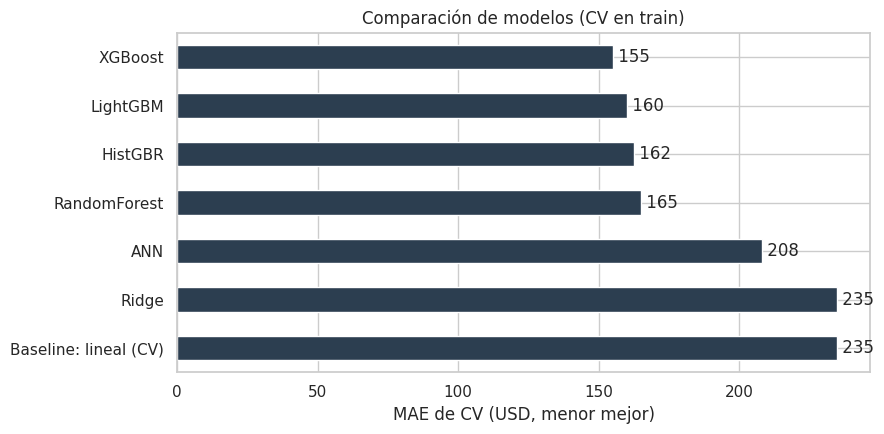

Mejor modelo: XGBoost | MAE CV = 154.94


In [9]:
cv_mae = {name: -gs.best_score_ for name, gs in searches.items()}
cv_mae["Baseline: lineal (CV)"] = -cross_val_score(
    make_pipeline(LinearRegression()), X_train, y_train,
    cv=cv, scoring=SCORING, n_jobs=-1).mean()

cmp = pd.Series(cv_mae).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
cmp.iloc[::-1].plot.barh(ax=ax, color="#2c3e50")
ax.set_xlabel("MAE de CV (USD, menor mejor)"); ax.set_title("Comparación de modelos (CV en train)")
for i, v in enumerate(cmp.iloc[::-1]): ax.text(v, i, f" {v:.0f}", va="center")
plt.tight_layout(); plt.savefig(OUT/"05_model_comparison.png", dpi=110); plt.show()

BEST_NAME = cmp.index[0]
best_model = searches[BEST_NAME].best_estimator_
print("Mejor modelo:", BEST_NAME, "| MAE CV =", round(cmp.iloc[0], 2))


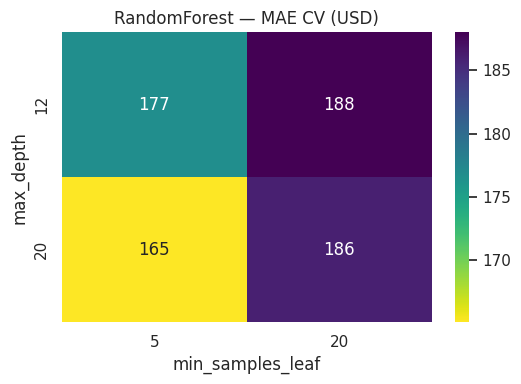

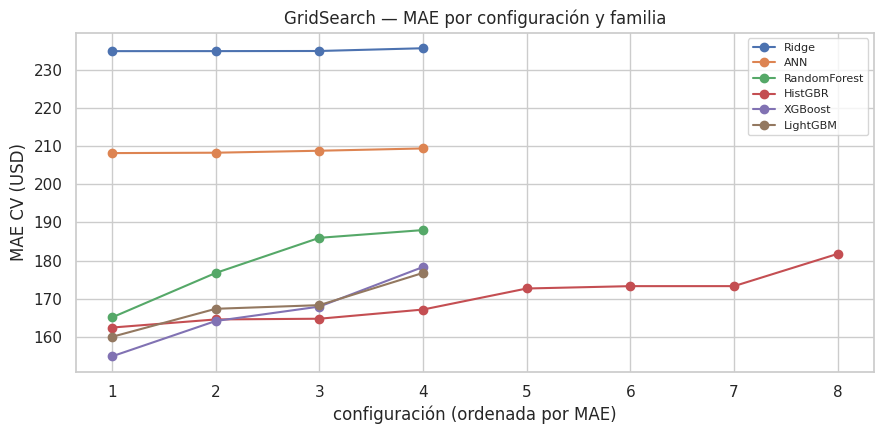

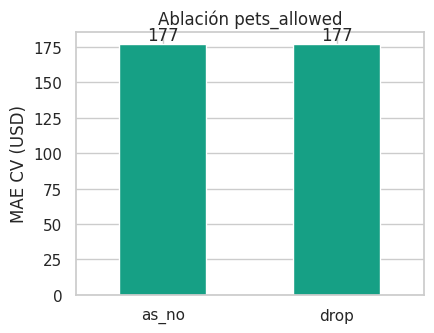

In [10]:
# --- Gráficos de los GridSearch (para la diapositiva final) ---
def gs_frame(gs):
    d = pd.DataFrame(gs.cv_results_)
    d["MAE"] = -d["mean_test_score"]
    return d

# 1) Heatmap RandomForest: max_depth x min_samples_leaf -> MAE CV
rf = gs_frame(searches["RandomForest"])
piv = rf.pivot_table(index="param_regressor__model__max_depth",
                     columns="param_regressor__model__min_samples_leaf", values="MAE")
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="viridis_r", ax=ax)
ax.set_title("RandomForest — MAE CV (USD)")
ax.set_xlabel("min_samples_leaf"); ax.set_ylabel("max_depth")
plt.tight_layout(); plt.savefig(OUT/"07_grid_rf_heatmap.png", dpi=110); plt.show()

# 2) Curva por familia: MAE CV de cada configuración probada (ordenada)
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, gs in searches.items():
    dd = gs_frame(gs).sort_values("MAE").reset_index(drop=True)
    ax.plot(range(1, len(dd) + 1), dd["MAE"], marker="o", label=name)
ax.set_xlabel("configuración (ordenada por MAE)"); ax.set_ylabel("MAE CV (USD)")
ax.set_title("GridSearch — MAE por configuración y familia"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT/"08_grid_curvas.png", dpi=110); plt.show()

# 3) Ablación de pets_allowed (as_no vs drop)
fig, ax = plt.subplots(figsize=(4.5, 3.5))
pd.Series(pets_scores).plot.bar(ax=ax, color="#16a085", rot=0)
ax.set_ylabel("MAE CV (USD)"); ax.set_title("Ablación pets_allowed")
for i, v in enumerate(pets_scores.values()):
    ax.text(i, v, f"{v:.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.savefig(OUT/"09_pets_ablacion.png", dpi=110); plt.show()

## 6. Evaluación del mejor modelo en TEST

                                 MAE    RMSE  MAPE%
MEJOR: XGBoost                162.74  299.04  10.34
Baseline: regresión lineal    243.53  418.38  15.56
Baseline: mediana por ciudad  344.55  547.38  22.58
Baseline: mediana global      494.45  762.31  32.92


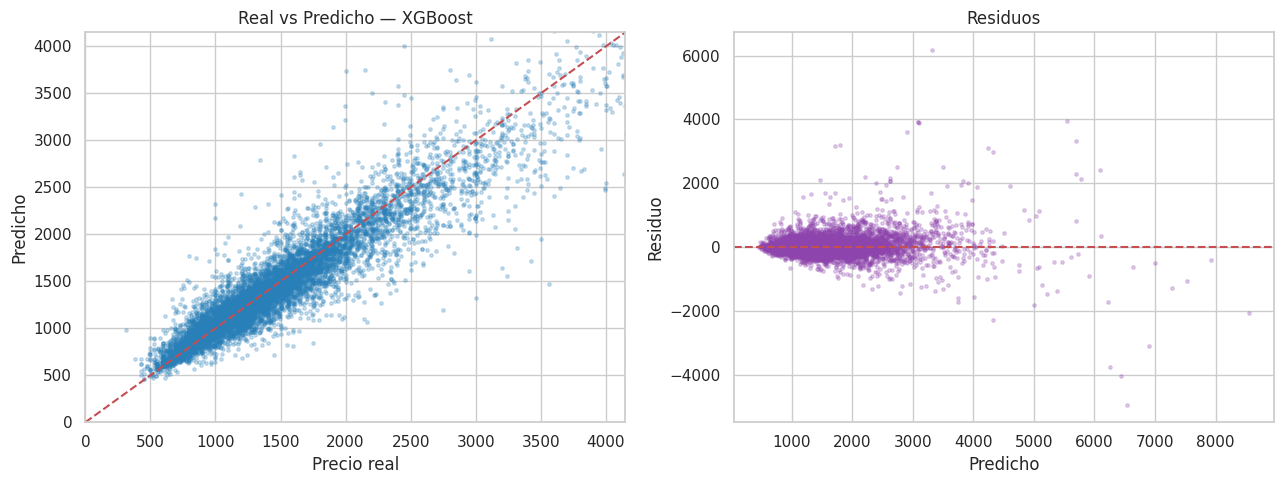

In [11]:
y_pred = best_model.predict(X_test)
results[f"MEJOR: {BEST_NAME}"] = metrics(y_test, y_pred)

tabla = pd.DataFrame(results).T.round(2).sort_values("MAE")
print(tabla.to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_test, y_pred, s=6, alpha=0.25, color="#2980b9")
lim = [0, np.percentile(y_test, 99)]
ax[0].plot(lim, lim, "r--"); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("Precio real"); ax[0].set_ylabel("Predicho"); ax[0].set_title(f"Real vs Predicho — {BEST_NAME}")
resid = y_test - y_pred
ax[1].scatter(y_pred, resid, s=6, alpha=0.25, color="#8e44ad")
ax[1].axhline(0, color="r", ls="--"); ax[1].set_xlabel("Predicho"); ax[1].set_ylabel("Residuo")
ax[1].set_title("Residuos")
plt.tight_layout(); plt.savefig(OUT/"06_test_eval.png", dpi=110); plt.show()


## 7. Intervalo de predicción (banda relativa sobre el MEJOR modelo)

Entregamos **un rango**, no un único número. En vez de entrenar modelos cuantílicos
aparte, calibramos la banda con los **residuos del mejor modelo** (el ganador del
GridSearch), así el rango refleja la precisión real de ese modelo:

1. Sacamos predicciones **out-of-fold** del mejor modelo sobre train (`cross_val_predict`,
   sin leakage) y calculamos el **error relativo** `|real - pred| / real`.
2. Tomamos el cuantil que da la cobertura buscada (p. ej. 90%) → una banda `±b%`.
3. El rango para una estimación es `pred × (1 ± b)`. Si `pred = 1500` y `b = 10%`,
   el rango es `1350 – 1650`.
4. Validamos la **cobertura empírica** en test (debería acercarse al objetivo).

Es una banda relativa (crece con el precio), calibrada empíricamente — no un `±10%` inventado.

In [12]:
CONF = 0.90   # cobertura objetivo de la banda

# 1) Error relativo out-of-fold del MEJOR modelo sobre train (clone para no re-usar el ajuste)
oof_pred = cross_val_predict(clone(best_model), X_train, y_train, cv=cv, n_jobs=-1)
rel_err = np.abs(y_train - oof_pred) / np.maximum(y_train, 1.0)

# 2) Banda: cuantil que cubre CONF de los errores relativos
band = float(np.quantile(rel_err, CONF))
print(f"Banda relativa calibrada al {CONF:.0%}: +/- {band*100:.1f}%")

# 3) Rango sobre la estimación del mejor modelo en test
lo = y_pred * (1 - band)
hi = y_pred * (1 + band)

# 4) Cobertura empírica en test
coverage = np.mean((y_test >= lo) & (y_test <= hi)) * 100
width = np.median(hi - lo)
print(f"Cobertura en test: {coverage:.1f}%  (objetivo {CONF:.0%})")
print(f"Ancho mediano del intervalo: USD {width:.0f}")

# Ejemplo de salida para el usuario: estimación +/- banda
ej = pd.DataFrame({"real": y_test[:8], "estimacion": y_pred[:8].round(0),
                   "rango_min": lo[:8].round(0), "rango_max": hi[:8].round(0)})
ej["banda_%"] = round(band * 100, 1)
ej

Banda relativa calibrada al 90%: +/- 22.3%
Cobertura en test: 89.2%  (objetivo 90%)
Ancho mediano del intervalo: USD 593


,real,estimacion,rango_min,rango_max,banda_%
0,875.0,1059.0,823.0,1295.0,22.3
1,852.0,909.0,706.0,1112.0,22.3
2,1757.0,1726.0,1341.0,2111.0,22.3
3,800.0,781.0,606.0,955.0,22.3
4,1275.0,1108.0,861.0,1355.0,22.3
5,2000.0,1975.0,1535.0,2416.0,22.3
6,974.0,1033.0,802.0,1263.0,22.3
7,1150.0,1143.0,888.0,1398.0,22.3


## 8. Persistencia del modelo

In [14]:
import json
joblib.dump(best_model, PROC/"best_pipeline.pkl")
# La banda es un solo escalar; se guarda junto al modelo en el info JSON.

def to_native(x):
    # np.float32/np.int64/etc -> tipos nativos serializables por json
    return x.item() if isinstance(x, np.generic) else x

info = {
    "best_model": BEST_NAME,
    "best_params": {k.split("__")[-1]: to_native(v)
                    for k, v in searches[BEST_NAME].best_params_.items()},
    "pets_mode": PETS_MODE,
    "test_metrics": {k: round(float(v), 3) for k, v in results[f"MEJOR: {BEST_NAME}"].items()},
    "interval": {"conf": CONF, "band_pct": round(band * 100, 2),
                 "coverage_pct": round(float(coverage), 1), "median_width_usd": round(float(width), 1)},
    "num_features": NUM_FEATURES, "cat_features": ["state", "pets_cat"],
}
with open(PROC/"best_model_info.json", "w") as f:
    json.dump(info, f, indent=2, ensure_ascii=False, default=to_native)
print(json.dumps(info, indent=2, ensure_ascii=False, default=to_native))

{
  "best_model": "XGBoost",
  "best_params": {
    "learning_rate": 0.07,
    "max_depth": 8
  },
  "pets_mode": "drop",
  "test_metrics": {
    "MAE": 162.74,
    "RMSE": 299.042,
    "MAPE%": 10.342
  },
  "interval": {
    "conf": 0.9,
    "band_pct": 22.31,
    "coverage_pct": 89.2,
    "median_width_usd": 592.9
  },
  "num_features": [
    "square_feet",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude",
    "dist_city_center",
    "knn_price",
    "city_price_median",
    "city_price_mean",
    "n_amenities",
    "has_amenities",
    "has_photo_bin",
    "fee_bin",
    "pets_known"
  ],
  "cat_features": [
    "state",
    "pets_cat"
  ]
}


## 9. Conclusiones

- Se compararon **6 familias de modelos** con `GridSearchCV`, sin fijarse a priori en
  ninguna; la selección fue **por MAE de CV**, contra baselines. Grids acotados (RF con
  `max_depth` limitado, ANN regularizada) para evitar overfitting y correr en tiempo razonable.
- La codificación de `pets_allowed` se decidió empíricamente vía ablación (sección 2).
- El mejor modelo supera claramente los baselines (mediana global / por ciudad / lineal).
- Entregamos **estimación puntual + banda relativa** calibrada con los residuos del mejor
  modelo (cobertura ~`CONF`) → comunica un **rango y una confianza** ligados a la precisión real.

**Siguiente:** `03_error_y_deploy.ipynb` — análisis de errores por cohorte, calibración del
intervalo, importancia de features, función predictora y discusión de uso real / monitoreo.